In [160]:
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import random
import numpy as np
from PIL import Image, ImageFilter
from PIL import ImageDraw, ImageEnhance
import yaml
import os
from torch.utils.data import Dataset

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Removes bounding boxes that are too small compared to image size
def filter_boxes_by_relative_size(boxes, image_width, image_height, min_size_ratio=0.03):
    min_w = image_width * min_size_ratio
    min_h = image_height * min_size_ratio

    filtered = []
    for cls, x1, y1, x2, y2 in boxes:
        w = x2 - x1
        h = y2 - y1
        if w >= min_w and h >= min_h:
            filtered.append((cls, x1, y1, x2, y2))
    return filtered

# Computes IoU (Intersection over Union) between two boxes (to remove pasted images that cover too much of another box)
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    if inter_area == 0:
        return 0.0

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter_area

    return inter_area / union


class RandomCutPasteWithBoxes:
    def __init__(self, image_dir, label_dir, p=0.8, max_iou=0.3):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".jpg")])
        self.p = p
        self.max_iou = max_iou

    def load_labels(self, label_path, img_width, img_height):
        boxes = []
        labels = []
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, x, y, w, h = map(float, line.strip().split())
                x1 = (x - w / 2) * img_width
                y1 = (y - h / 2) * img_height
                x2 = (x + w / 2) * img_width
                y2 = (y + h / 2) * img_height
                boxes.append([x1, y1, x2, y2])
                labels.append(int(cls))
        return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.long)

    def __call__(self, img, target):
        if random.random() > self.p or len(target["boxes"]) == 0:
            return img, target

        width, height = img.size

        donor_idx = random.randint(0, len(self.image_files) - 1)
        donor_name = self.image_files[donor_idx]
        donor_img_path = os.path.join(self.image_dir, donor_name)
        donor_label_path = os.path.join(self.label_dir, donor_name.replace(".jpg", ".txt"))

        donor_img = Image.open(donor_img_path).convert("RGB")
        donor_w, donor_h = donor_img.size

        donor_boxes, donor_labels = self.load_labels(donor_label_path, donor_w, donor_h)
        if len(donor_boxes) == 0:
            return img, target

        idx = random.randint(0, len(donor_boxes) - 1)
        x1, y1, x2, y2 = donor_boxes[idx].tolist()
        cls = donor_labels[idx].item()

        crop_w, crop_h = x2 - x1, y2 - y1
        if crop_w >= width or crop_h >= height:
            return img, target

        donor_crop = donor_img.crop((x1, y1, x2, y2))

        paste_x = random.randint(0, width - int(crop_w))
        paste_y = random.randint(0, height - int(crop_h))
        new_box = [paste_x, paste_y, paste_x + crop_w, paste_y + crop_h]

        # Avoid pasting over existing boxes
        for box in target["boxes"]:
            if compute_iou(box.tolist(), new_box) > self.max_iou:
                return img, target

        img.paste(donor_crop, (paste_x, paste_y))
        new_boxes = torch.cat([target["boxes"], torch.tensor([new_box], dtype=torch.float32)], dim=0)
        new_labels = torch.cat([target["labels"], torch.tensor([cls], dtype=torch.long)], dim=0)

        target["boxes"] = new_boxes
        target["labels"] = new_labels
        return img, target
    
"""
class RandomResizedCropWithBoxes:
    def __init__(self, size, scale=(0.7, 1.0), ratio=(3. / 4., 4. / 3.), min_size_ratio=0.05):
        self.size = size  # final output size (e.g. 416)
        self.scale = scale
        self.ratio = ratio
        self.min_size_ratio = min_size_ratio

    def get_params(self, img):
        width, height = img.size
        area = height * width

        for _ in range(10):
            target_area = random.uniform(*self.scale) * area
            aspect_ratio = random.uniform(*self.ratio)

            w = int(round((target_area * aspect_ratio) ** 0.5))
            h = int(round((target_area / aspect_ratio) ** 0.5))

            if w <= width and h <= height:
                i = random.randint(0, height - h)
                j = random.randint(0, width - w)
                return i, j, h, w

        # Fallback to center crop
        in_ratio = width / height
        if in_ratio < self.ratio[0]:
            w = width
            h = int(round(w / self.ratio[0]))
        elif in_ratio > self.ratio[1]:
            h = height
            w = int(round(h * self.ratio[1]))
        else:
            w = width
            h = height
        i = (height - h) // 2
        j = (width - w) // 2
        return i, j, h, w

    def __call__(self, img, target):
        i, j, h, w = self.get_params(img)

        # Crop and resize image
        img = TF.resized_crop(img, top=i, left=j, height=h, width=w, size=(self.size, self.size))

        boxes = target["boxes"]
        labels = target["labels"]

        # Adjust boxes
        boxes_out = []
        labels_out = []

        scale_x = self.size / w
        scale_y = self.size / h

        for k in range(boxes.shape[0]):
            x1, y1, x2, y2 = boxes[k]
            x1_new = (x1 - j) * scale_x
            y1_new = (y1 - i) * scale_y
            x2_new = (x2 - j) * scale_x
            y2_new = (y2 - i) * scale_y

            # Clip
            x1_new = max(0, min(self.size, x1_new))
            y1_new = max(0, min(self.size, y1_new))
            x2_new = max(0, min(self.size, x2_new))
            y2_new = max(0, min(self.size, y2_new))

            new_w = x2_new - x1_new
            new_h = y2_new - y1_new

            if new_w >= self.size * self.min_size_ratio and new_h >= self.size * self.min_size_ratio:
                boxes_out.append([x1_new, y1_new, x2_new, y2_new])
                labels_out.append(labels[k])

        if boxes_out:
            target["boxes"] = torch.tensor(boxes_out, dtype=torch.float32)
            target["labels"] = torch.tensor(labels_out, dtype=torch.long)
        else:
            target["boxes"] = torch.empty((0, 4), dtype=torch.float32)
            target["labels"] = torch.empty((0,), dtype=torch.long)

        return img, target"""

class RandomResizedCropWithBoxes:
    def __init__(self, size, scale=(0.7, 1.0), ratio=(3. / 4., 4. / 3.), min_size_ratio=0.01):
        self.size = size
        self.scale = scale
        self.ratio = ratio
        self.min_size_ratio = min_size_ratio

    def get_params(self, img):
        width, height = img.size
        area = height * width

        for _ in range(10):
            target_area = random.uniform(*self.scale) * area
            aspect_ratio = random.uniform(*self.ratio)

            w = int(round((target_area * aspect_ratio) ** 0.5))
            h = int(round((target_area / aspect_ratio) ** 0.5))

            if w <= width and h <= height:
                top = random.randint(0, height - h)
                left = random.randint(0, width - w)
                return top, left, h, w

        # fallback to center crop
        in_ratio = width / height
        if in_ratio < self.ratio[0]:
            w = width
            h = int(round(w / self.ratio[0]))
        elif in_ratio > self.ratio[1]:
            h = height
            w = int(round(h * self.ratio[1]))
        else:
            w = width
            h = height
        top = (height - h) // 2
        left = (width - w) // 2
        return top, left, h, w

    def __call__(self, img, target):
        top, left, h, w = self.get_params(img)
        img = TF.resized_crop(img, top=top, left=left, height=h, width=w, size=(self.size, self.size))

        boxes = target["boxes"]
        labels = target["labels"]

        scale_x = self.size / w
        scale_y = self.size / h

        kept = 0
        dropped = 0

        boxes_out = []
        labels_out = []

        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box.tolist()

            x1_new = (x1 - left) * scale_x
            y1_new = (y1 - top) * scale_y
            x2_new = (x2 - left) * scale_x
            y2_new = (y2 - top) * scale_y

            x1_new = max(0, min(self.size, x1_new))
            y1_new = max(0, min(self.size, y1_new))
            x2_new = max(0, min(self.size, x2_new))
            y2_new = max(0, min(self.size, y2_new))

            bw = x2_new - x1_new
            bh = y2_new - y1_new
            area = bw * bh

            if bw > 1 and bh > 1:
                boxes_out.append([x1_new, y1_new, x2_new, y2_new])
                labels_out.append(label)
                kept += 1
            else:
                dropped += 1


        if boxes_out:
            target["boxes"] = torch.tensor(boxes_out, dtype=torch.float32)
            target["labels"] = torch.tensor(labels_out, dtype=torch.long)
        else:
            target["boxes"] = torch.empty((0, 4), dtype=torch.float32)
            target["labels"] = torch.empty((0,), dtype=torch.long)

        return img, target



class RandomVerticalFlipWithBoxes:
    def __init__(self, p=0.2):
        self.p = p

    def __call__(self, img, target):
        if random.random() > self.p:
            return img, target

        img = TF.vflip(img)
        h = img.size[1]

        boxes = target["boxes"].clone()
        boxes[:, [1, 3]] = h - boxes[:, [3, 1]]  # flip y1, y2
        target["boxes"] = boxes
        return img, target

class RandomBlackLinesWithTarget:
    def __init__(self, p=0.5, max_lines=5, max_thickness=5):
        self.p = p
        self.max_lines = max_lines
        self.max_thickness = max_thickness

    def __call__(self, img, target):
        if random.random() > self.p:
            return img, target

        draw = ImageDraw.Draw(img)
        for _ in range(random.randint(1, self.max_lines)):
            x1 = random.randint(0, img.width)
            y1 = random.randint(0, img.height)
            x2 = random.randint(0, img.width)
            y2 = random.randint(0, img.height)
            thickness = random.randint(2, self.max_thickness)
            draw.line((x1, y1, x2, y2), fill=(0, 0, 0), width=thickness)

        return img, target

class RandomGaussianNoise:
    def __init__(self, mean=0., std=0.01, p=0.3):
        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            noise = torch.randn_like(tensor) * self.std + self.mean
            return tensor + noise
        return tensor

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std}, p={self.p})"

# Applies random Gaussian blur to an image
class RandomGaussianBlur:
    def __init__(self, radius_min=0.1, radius_max=0.5):
        self.radius_min = radius_min
        self.radius_max = radius_max

    def __call__(self, img):
        radius = random.uniform(self.radius_min, self.radius_max)
        return img.filter(ImageFilter.GaussianBlur(radius))
    
class ComposeBoxTransforms:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, target):
        for t in self.transforms:
            img, target = t(img, target)
        return img, target

class RandomHorizontalFlipWithBoxes:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, img, target):
        if random.random() > self.p:
            return img, target

        img = TF.hflip(img)
        w = img.size[0]  # width

        boxes = target["boxes"].clone()
        boxes[:, [0, 2]] = w - boxes[:, [2, 0]]  # flip x1 and x2
        target["boxes"] = boxes
        return img, target

"""
box_transforms = ComposeBoxTransforms([
    RandomCutPasteWithBoxes(
    image_dir="/Users/lunnet_1/Downloads/EPFL/MA2/Image_analysis/EE-451/data/train/images",
    label_dir="/Users/lunnet_1/Downloads/EPFL/MA2/Image_analysis/EE-451/data/train/labels",
    p=1,
    max_iou=0.3
),
    #RandomResizedCropWithBoxes(size=150),
    RandomHorizontalFlipWithBoxes(p=0.5),
    RandomVerticalFlipWithBoxes(p=0.5),
    #RandomBlackLinesWithTarget(...),
])
"""




# Adds random black lines to simulate occlusions (like headbands)
class RandomBlackLines:
    def __init__(self, p=0.5, max_lines=5, max_thickness=5):
        self.p = p
        self.max_lines = max_lines
        self.max_thickness = max_thickness

    def __call__(self, img):
        if random.random() > self.p:
            return img

        draw = ImageDraw.Draw(img)
        num_lines = random.randint(1, self.max_lines)

        for _ in range(num_lines):
            x1 = random.randint(0, img.width)
            y1 = random.randint(0, img.height)
            x2 = random.randint(0, img.width)
            y2 = random.randint(0, img.height)
            thickness = random.randint(2, self.max_thickness)
            draw.line((x1, y1, x2, y2), fill=(0, 0, 0), width=thickness)

        return img
    
class RandomBlackLinesWithTarget:
    def __init__(self, p=0.5, max_lines=5, max_thickness=5):
        self.p = p
        self.max_lines = max_lines
        self.max_thickness = max_thickness

    def __call__(self, img, target):
        if random.random() > self.p:
            return img, target

        draw = ImageDraw.Draw(img)
        for _ in range(random.randint(1, self.max_lines)):
            x1 = random.randint(0, img.width)
            y1 = random.randint(0, img.height)
            x2 = random.randint(0, img.width)
            y2 = random.randint(0, img.height)
            thickness = random.randint(2, self.max_thickness)
            draw.line((x1, y1, x2, y2), fill=(0, 0, 0), width=thickness)

        return img, target
    

class RandomSubsetTransformWithTarget:
    def __init__(self, transforms, num_choices=2):
        self.transforms = transforms
        self.num_choices = num_choices

    def __call__(self, img, target):
        chosen_transforms = random.sample(self.transforms, min(self.num_choices, len(self.transforms)))
        for t in chosen_transforms:
            img, target = t(img, target)
        return img, target

class WrapperForImageOnlyTransform:
    def __init__(self, image_transform):
        self.image_transform = image_transform

    def __call__(self, img, target):
        img = self.image_transform(img)
        return img, target
    
image_only_transforms = [
    WrapperForImageOnlyTransform(T.ColorJitter(brightness=0.1, contrast=0.2, saturation=0.2, hue=0.05)),
    WrapperForImageOnlyTransform(RandomGaussianBlur()),
    #WrapperForImageOnlyTransform(RandomBlackLines()),
]

random_subset_with_target = RandomSubsetTransformWithTarget(image_only_transforms, num_choices=2)



In [161]:
def load_yolo_annotations(ann_path):
    boxes = []
    labels = []
    if not os.path.exists(ann_path):
        return torch.empty((0, 4), dtype=torch.float32), torch.empty((0,), dtype=torch.int64)

    with open(ann_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            class_id = int(parts[0])
            cx, cy, w, h = map(float, parts[1:])
            # YOLO format is normalized cx, cy, w, h
            # DDETR expects normalized cx, cy, w, h as well
            boxes.append([cx, cy, w, h])
            labels.append(class_id)
    if not boxes:
        return torch.empty((0, 4), dtype=torch.float32), torch.empty((0,), dtype=torch.int64)
    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)

class YOLODataset(Dataset):
    def __init__(self, img_dir, ann_dir, img_size, num_classes, transform=None, is_train=True):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.img_size = img_size
        self.num_classes = num_classes
        self.transform = transform
        self.is_train = is_train

        self.img_files = os.listdir(img_dir) # Add other extensions if needed

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = image.size

        ann_filename = os.path.splitext(os.path.basename(img_path))[0] + ".txt"
        ann_path = os.path.join(self.ann_dir, ann_filename)

        boxes, labels = load_yolo_annotations(ann_path)  # boxes in cx, cy, w, h

        # Convert to absolute (x1, y1, x2, y2) in pixels
        boxes_xyxy = boxes.clone()
        boxes_xyxy[:, 0] = (boxes[:, 0] - boxes[:, 2] / 2) * orig_w  # x1
        boxes_xyxy[:, 1] = (boxes[:, 1] - boxes[:, 3] / 2) * orig_h  # y1
        boxes_xyxy[:, 2] = (boxes[:, 0] + boxes[:, 2] / 2) * orig_w  # x2
        boxes_xyxy[:, 3] = (boxes[:, 1] + boxes[:, 3] / 2) * orig_h  # y2

        target = {
            "boxes": boxes_xyxy,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "orig_size": torch.tensor([orig_h, orig_w]),
            "size": torch.tensor([self.img_size, self.img_size])
        }

        if self.transform:
            image, target = self.transform(image, target)

        # 🔁 Convert back to (cx, cy, w, h) normalized
        final_w, final_h = image.size
        boxes = target["boxes"]
        if len(boxes) > 0:
            cx = ((boxes[:, 0] + boxes[:, 2]) / 2) / final_w
            cy = ((boxes[:, 1] + boxes[:, 3]) / 2) / final_h
            bw = (boxes[:, 2] - boxes[:, 0]) / final_w
            bh = (boxes[:, 3] - boxes[:, 1]) / final_h
            target["boxes"] = torch.stack([cx, cy, bw, bh], dim=1)
        else:
            target["boxes"] = torch.empty((0, 4), dtype=torch.float32)

        return image, target



In [162]:
"""def load_yolo_annotations(ann_path):
    boxes = []
    labels = []
    if not os.path.exists(ann_path):
        return torch.empty((0, 4), dtype=torch.float32), torch.empty((0,), dtype=torch.int64)

    with open(ann_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            class_id = int(parts[0])
            cx, cy, w, h = map(float, parts[1:])
            # YOLO format is normalized cx, cy, w, h
            # DDETR expects normalized cx, cy, w, h as well
            boxes.append([cx, cy, w, h])
            labels.append(class_id)
    if not boxes:
        return torch.empty((0, 4), dtype=torch.float32), torch.empty((0,), dtype=torch.int64)
    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)

class YOLODataset(Dataset):
    def __init__(self, img_dir, ann_dir, img_size, num_classes, transform=None, is_train=True):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.img_size = img_size
        self.num_classes = num_classes
        self.transform = transform
        self.is_train = is_train

        self.img_files = os.listdir(img_dir) # Add other extensions if needed

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        #img_path = self.img_files[idx]
        image = Image.open(img_path).convert("RGB")
        original_w, original_h = image.size

        ann_filename = os.path.splitext(os.path.basename(img_path))[0] + ".txt"
        ann_path = os.path.join(self.ann_dir, ann_filename)

        boxes, labels = load_yolo_annotations(ann_path)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx])}
        target["orig_size"] = torch.as_tensor([int(original_h), int(original_w)])
        target["size"] = torch.as_tensor([self.img_size, self.img_size]) # After resize

        if self.transform:
            image, target = self.transform(image, target) # Custom transform for DDETR

        return image, target"""


'def load_yolo_annotations(ann_path):\n    boxes = []\n    labels = []\n    if not os.path.exists(ann_path):\n        return torch.empty((0, 4), dtype=torch.float32), torch.empty((0,), dtype=torch.int64)\n\n    with open(ann_path, \'r\') as f:\n        for line in f:\n            parts = line.strip().split()\n            class_id = int(parts[0])\n            cx, cy, w, h = map(float, parts[1:])\n            # YOLO format is normalized cx, cy, w, h\n            # DDETR expects normalized cx, cy, w, h as well\n            boxes.append([cx, cy, w, h])\n            labels.append(class_id)\n    if not boxes:\n        return torch.empty((0, 4), dtype=torch.float32), torch.empty((0,), dtype=torch.int64)\n    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)\n\nclass YOLODataset(Dataset):\n    def __init__(self, img_dir, ann_dir, img_size, num_classes, transform=None, is_train=True):\n        self.img_dir = img_dir\n        self.ann_dir = ann_dir\n       

In [163]:
def unnormalize(img_or_tensor):
    if isinstance(img_or_tensor, torch.Tensor):
        return img_or_tensor * 0.5 + 0.5  # unnormalize if tensor
    return img_or_tensor  # return PIL image as-is

def visualize_yolo_dataset(dataset, rows=2, cols=4, class_names=None):
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()

    for ax in axes:
        idx = torch.randint(0, len(dataset), (1,)).item()
        img, target = dataset[idx]

        # Handle both tensor and PIL image
        if isinstance(img, torch.Tensor):
            img = TF.to_pil_image(unnormalize(img))
        else:
            img = img

        ax.imshow(img)
        ax.axis("off")

        w, h = img.size
        for box, label in zip(target["boxes"], target["labels"]):
            cx, cy, bw, bh = box
            x1 = int((cx - bw / 2) * w)
            y1 = int((cy - bh / 2) * h)
            x2 = int((cx + bw / 2) * w)
            y2 = int((cy + bh / 2) * h)


            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)

            if class_names:
                cls = int(label)
                if 0 <= cls < len(class_names):
                    ax.text(x1, y1 - 4, class_names[cls], fontsize=8, color="white",
                            bbox=dict(facecolor="green", pad=0, edgecolor='none'))

    plt.tight_layout()
    plt.show()



In [164]:
class LogTransform:
    def __init__(self, transform, name=None):
        self.transform = transform
        self.name = name or transform.__class__.__name__

    def __call__(self, img, target):
        before = len(target["boxes"])
        img, target = self.transform(img, target)
        after = len(target["boxes"])
        print(f"{self.name}: {before} → {after} boxes")
        return img, target


In [165]:
def yolo_collate_fn(batch):
    images = []
    targets = []

    for i, (img, target) in enumerate(batch):
        target = target.copy()
        target["image_id"] = torch.tensor([i])
        images.append(img)
        targets.append(target)

    images = torch.stack(images)
    return images, targets


In [166]:
final_transform = ComposeBoxTransforms([
    LogTransform(RandomCutPasteWithBoxes(
        image_dir="/Users/lunnet_1/Downloads/EPFL/MA2/Image_analysis/EE-451/data/train/images",
        label_dir="/Users/lunnet_1/Downloads/EPFL/MA2/Image_analysis/EE-451/data/train/labels",
        p=1.0,
        max_iou=0.3
    )),
    LogTransform(RandomResizedCropWithBoxes(size=150)),
    LogTransform(RandomHorizontalFlipWithBoxes(p=0.5)),
    LogTransform(RandomVerticalFlipWithBoxes(p=0.5)),
    LogTransform(RandomBlackLinesWithTarget(p=0.5)),
])


In [167]:
dataset = YOLODataset(
    img_dir="/Users/lunnet_1/Downloads/EPFL/MA2/Image_analysis/EE-451/data/train/images",
    ann_dir="/Users/lunnet_1/Downloads/EPFL/MA2/Image_analysis/EE-451/data/train/labels",
    img_size=360,                         # target image size (must match crop size)
    num_classes=14,                       # total number of classes
    transform=final_transform
)


RandomCutPasteWithBoxes: 6 → 7 boxes
RandomResizedCropWithBoxes: 7 → 7 boxes
RandomHorizontalFlipWithBoxes: 7 → 7 boxes
RandomVerticalFlipWithBoxes: 7 → 7 boxes
RandomBlackLinesWithTarget: 7 → 7 boxes
RandomCutPasteWithBoxes: 1 → 2 boxes
RandomResizedCropWithBoxes: 2 → 2 boxes
RandomHorizontalFlipWithBoxes: 2 → 2 boxes
RandomVerticalFlipWithBoxes: 2 → 2 boxes
RandomBlackLinesWithTarget: 2 → 2 boxes
RandomCutPasteWithBoxes: 1 → 2 boxes
RandomResizedCropWithBoxes: 2 → 2 boxes
RandomHorizontalFlipWithBoxes: 2 → 2 boxes
RandomVerticalFlipWithBoxes: 2 → 2 boxes
RandomBlackLinesWithTarget: 2 → 2 boxes
RandomCutPasteWithBoxes: 8 → 9 boxes
RandomResizedCropWithBoxes: 9 → 9 boxes
RandomHorizontalFlipWithBoxes: 9 → 9 boxes
RandomVerticalFlipWithBoxes: 9 → 9 boxes
RandomBlackLinesWithTarget: 9 → 9 boxes
RandomCutPasteWithBoxes: 5 → 6 boxes
RandomResizedCropWithBoxes: 6 → 6 boxes
RandomHorizontalFlipWithBoxes: 6 → 6 boxes
RandomVerticalFlipWithBoxes: 6 → 6 boxes
RandomBlackLinesWithTarget: 6 → 6 b

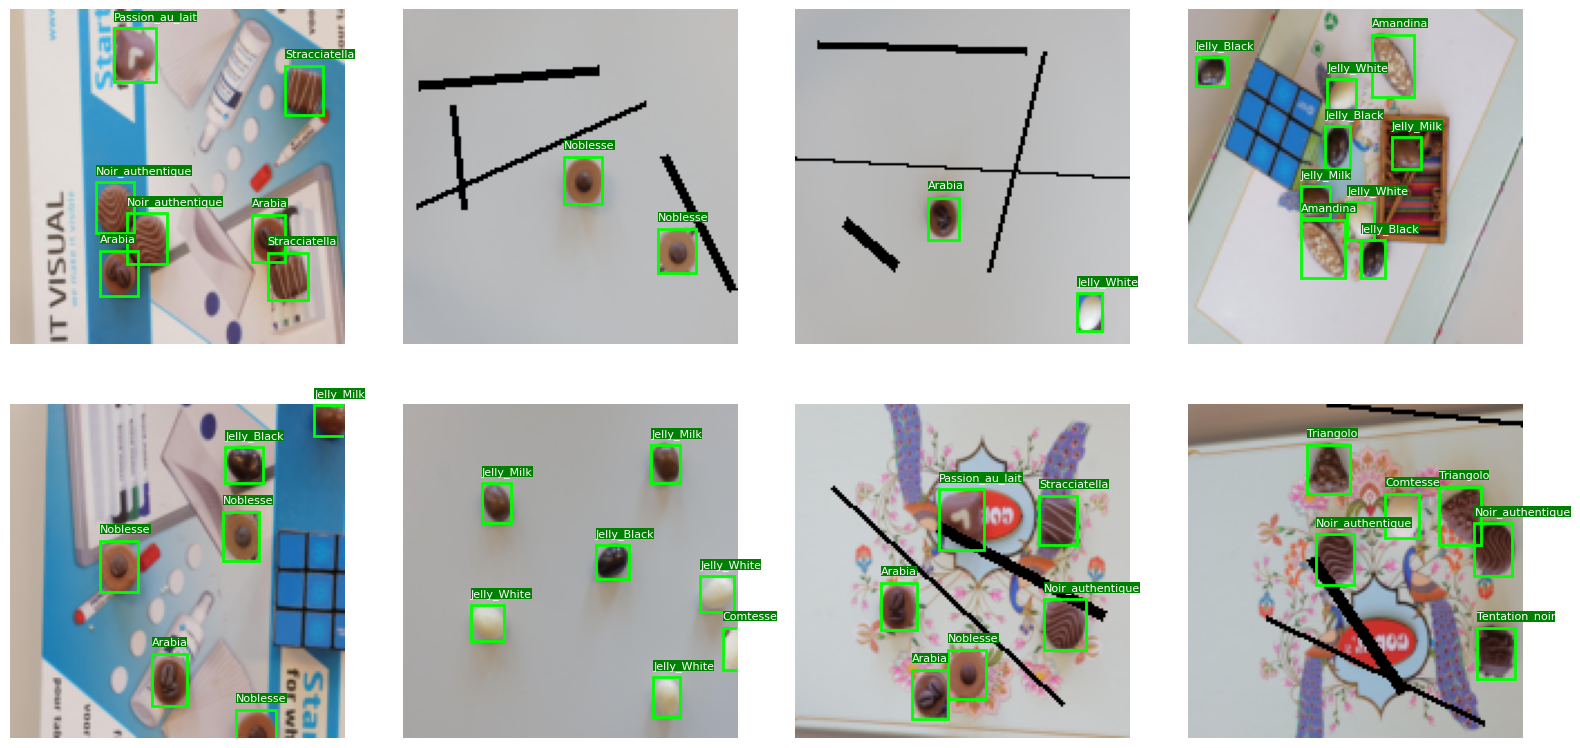

In [168]:
visualize_yolo_dataset(
    dataset,
    rows=2,
    cols=4,
    class_names=[
        'Amandina', 'Arabia', 'Comtesse', 'Creme_brulee', 'Jelly_Black',
        'Jelly_Milk', 'Jelly_White', 'Noblesse', 'Noir_authentique',
        'Passion_au_lait', 'Stracciatella', 'Tentation_noir', 'Triangolo'
    ])
